# Real-data experiment 2: hematopoietic boundary cells

This notebook studies paired RNA and index-sorting FACS measurements for mouse hematopoietic stem and progenitor cells. The mixture is fitted only to nine RNA principal components. FACS measurements and author phenotypes are withheld until evaluation, where FACS neighborhood mixing provides an external proxy for boundary or transition status.

We examine two uncertainty summaries: posterior mean responsibility entropy and the local median width of BMTS intervals over RNA-neighbor pairs. The analysis includes quality-control adjustment, stratified bootstrap and permutation inference, and sensitivity to mixture and neighborhood choices. Effects are interpreted modestly rather than as definitive cell-state labels.


In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "bmts.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bmts

bmts.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = False
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")


Public root located. PAPER_SCALE=False


In [2]:
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = bmts.load_nestorowa()
X_source = np.asarray(data["rna_pcs"], dtype=float)
fine_source = np.asarray(data["fine"]).astype("U32")
gate_source = np.asarray(data["gate"]).astype("U32")
broad_source = np.asarray(data["broad"]).astype("U32")
facs_source = np.asarray(data["facs"], dtype=float)
library_source = np.asarray(data["library_size"], dtype=float)
detected_source = np.asarray(data["detected_genes"], dtype=float)
ercc_source = np.asarray(data["ercc_percent"], dtype=float)

fine_levels = np.array(["LTHSC", "MPP", "CMP", "GMP", "MEP", "LMPP"])
facs_scores_source = {
    neighbors: bmts.facs_neighborhood_mixing(
        facs_source, fine_source, fine_levels, neighbors=neighbors
    )
    for neighbors in (10, 20, 30)
}
facs_observed_source = np.all(np.isfinite(facs_source), axis=1)

pd.Series(
    {
        "RNA-profiled cells": len(X_source),
        "RNA principal components": X_source.shape[1],
        "complete FACS cells": int(facs_observed_source.sum()),
        "missing-FACS cells excluded from evaluation": int((~facs_observed_source).sum()),
        "conventionally fine-gated cells": int(np.sum(fine_source != "")),
    },
    name="public derivative audit",
).to_frame("count")


,count
RNA-profiled cells,1656
RNA principal components,9
complete FACS cells,1430
missing-FACS cells excluded from evaluation,226
conventionally fine-gated cells,1203


In [3]:
# Fit order is randomized without consulting FACS values or phenotypes.
order = np.random.default_rng(9270).permutation(len(X_source))
X = X_source[order]
fine = fine_source[order]
gate = gate_source[order]
broad = broad_source[order]
library = library_source[order]
detected = detected_source[order]
ercc = ercc_source[order]
facs_observed = facs_observed_source[order]
facs_scores = {key: value[order] for key, value in facs_scores_source.items()}

initial = KMeans(n_clusters=4, n_init=30, random_state=9271).fit(X)
covariance = bmts.pooled_within_covariance(X, initial.labels_, ridge=0.05)
settings = (
    {"iterations": 1200, "burn": 400, "thin": 4}
    if PAPER_SCALE
    else {"iterations": 700, "burn": 250, "thin": 5}
)
fit = bmts.sample_common_covariance_gmm(
    X, 4, covariance, seed=9271, initial_labels=initial.labels_,
    concentration=1.0, prior_scale=25.0, **settings,
)

rna_neighbors, pairs = bmts.neighbor_pairs(X, 30)
posterior = bmts.posterior_bmts(
    fit.means, fit.responsibilities, pairs=pairs, dtype=np.float32
)
entropy = bmts.responsibility_entropy(fit.responsibilities)
local_width = bmts.local_pair_medians(
    posterior.width, rna_neighbors, pairs, neighbors=20
)
local_mean = bmts.local_pair_medians(
    posterior.mean, rna_neighbors, pairs, neighbors=20
)
entropy_rank = bmts.percentile_rank(entropy)
width_rank = bmts.percentile_rank(local_width)
facs_boundary = facs_scores[30]
evaluation = facs_observed

rho_entropy = spearmanr(entropy[evaluation], facs_boundary[evaluation])
rho_width = spearmanr(local_width[evaluation], facs_boundary[evaluation])
print(f"Retained draws: {fit.n_draws}; RNA-neighbor pairs: {len(pairs):,}")
quick_associations = pd.DataFrame(
    {
        "RNA uncertainty summary": ["Responsibility entropy", "Local BMTS interval width"],
        "Spearman rho with FACS mixing": [rho_entropy.statistic, rho_width.statistic],
        "asymptotic p-value": [rho_entropy.pvalue, rho_width.pvalue],
    }
).round(4)
display(quick_associations)
paper_associations = paper["nestorowa_hspc"]["primary_associations"]
pd.DataFrame({
    "paper-scale summary": ["Responsibility entropy", "Local BMTS interval width"],
    "Spearman rho with FACS mixing": [paper_associations["entropy_facs_spearman"], paper_associations["local_width_facs_spearman"]],
    "QC-adjusted rho": [paper_associations["qc_adjusted_entropy_facs_spearman"], paper_associations["qc_adjusted_local_width_facs_spearman"]],
}).round(4)


Retained draws: 90; RNA-neighbor pairs: 33,522


,RNA uncertainty summary,Spearman rho with FACS mixing,asymptotic p-value
0,Responsibility entropy,0.1009,0.0001
1,Local BMTS interval width,0.1001,0.0002


,paper-scale summary,Spearman rho with FACS mixing,QC-adjusted rho
0,Responsibility entropy,0.1008,0.0873
1,Local BMTS interval width,0.1012,0.0930


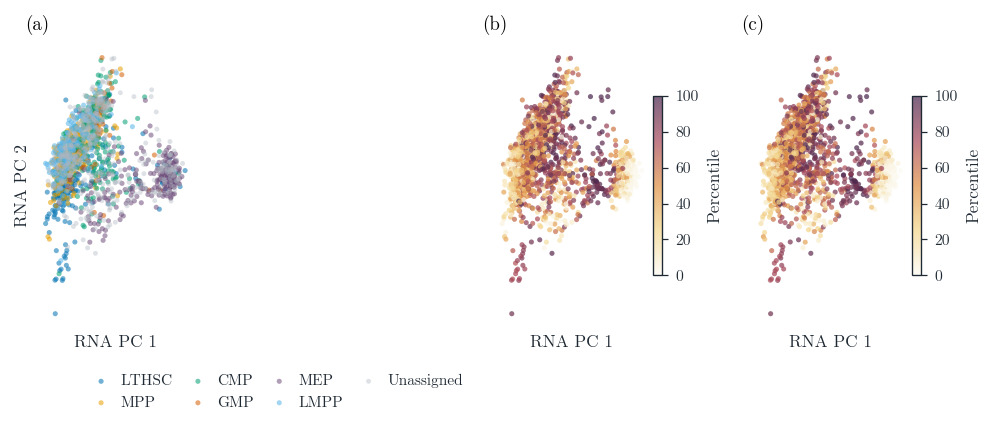

In [4]:
hspc_colors = {
    "LTHSC": bmts.BLUE, "MPP": bmts.ORANGE, "CMP": bmts.GREEN,
    "GMP": bmts.VERMILLION, "MEP": bmts.PURPLE, "LMPP": bmts.SKY,
}
known = fine != ""
fig, axes = plt.subplots(1, 3, figsize=(bmts.TEXT_WIDTH_IN, 2.75), constrained_layout=True, sharex=True, sharey=True)
for level in fine_levels:
    mask = fine == level
    axes[0].scatter(X[mask, 0], X[mask, 1], s=6, color=hspc_colors[level], alpha=0.55, edgecolor="none", rasterized=True, label=level)
axes[0].scatter(X[~known, 0], X[~known, 1], s=5.5, color="#AEB6BF", alpha=0.40, edgecolor="none", rasterized=True, label="Unassigned")

entropy_map = axes[1].scatter(
    X[:, 0], X[:, 1], c=100 * entropy_rank, s=6,
    cmap=bmts.UNCERTAINTY_CMAP, vmin=0, vmax=100,
    alpha=0.72, edgecolor="none", rasterized=True,
)
width_map = axes[2].scatter(
    X[:, 0], X[:, 1], c=100 * width_rank, s=6,
    cmap=bmts.UNCERTAINTY_CMAP, vmin=0, vmax=100,
    alpha=0.72, edgecolor="none", rasterized=True,
)
fig.colorbar(entropy_map, ax=axes[1], fraction=0.052, pad=0.025, label="Percentile")
fig.colorbar(width_map, ax=axes[2], fraction=0.052, pad=0.025, label="Percentile")
for index, ax in enumerate(axes):
    ax.set_xlabel("RNA PC 1")
    if index == 0:
        ax.set_ylabel("RNA PC 2")
    ax.set_aspect("equal", adjustable="box")
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    bmts.panel_label(ax, f"({chr(97 + index)})")
axes[0].legend(loc="upper center", ncol=4, bbox_to_anchor=(1.55, -0.12))
plt.show()


**Figure 1.** RNA-PC maps of (a) withheld fine phenotype, (b) responsibility-entropy percentile, and (c) local BMTS interval-width percentile. Phenotypes are shown only after the RNA-only fit; unassigned cells are retained rather than relabeled.


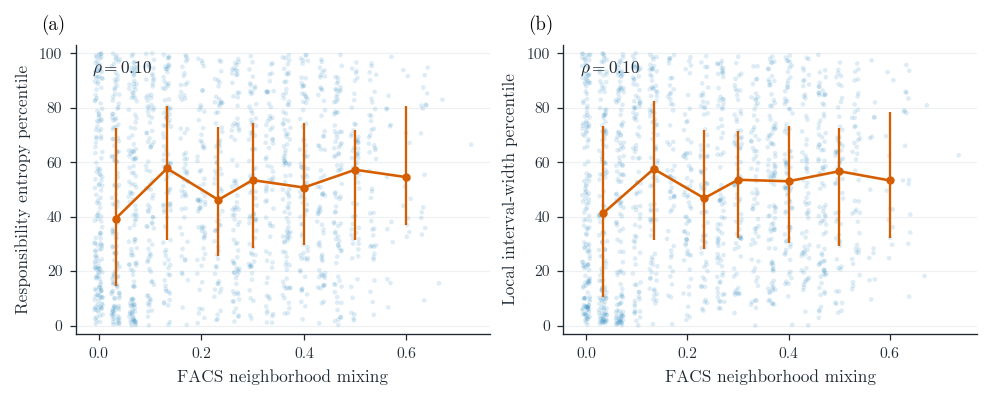

In [5]:
def binned_relation(ax, metric_rank, rho, ylabel, seed):
    rng = np.random.default_rng(seed)
    x = facs_boundary[evaluation]
    y = 100 * metric_rank[evaluation]
    ax.scatter(x + rng.uniform(-0.008, 0.008, len(x)), y, s=5, color=bmts.BLUE, alpha=0.13, edgecolor="none", rasterized=True)
    edges = np.linspace(x.min() - 1e-9, x.max() + 1e-9, 9)
    bins = np.digitize(x, edges[1:-1])
    centers, medians, lows, highs = [], [], [], []
    for bin_id in range(8):
        mask = bins == bin_id
        if mask.sum() < 10:
            continue
        centers.append(np.median(x[mask]))
        q1, median, q3 = np.quantile(y[mask], [0.25, 0.5, 0.75])
        lows.append(q1); medians.append(median); highs.append(q3)
    centers = np.asarray(centers)
    ax.vlines(centers, lows, highs, color=bmts.VERMILLION, linewidth=1.1)
    ax.plot(centers, medians, color=bmts.VERMILLION, marker="o", markersize=3)
    ax.text(0.04, 0.95, rf"$\rho={rho:.2f}$", transform=ax.transAxes, ha="left", va="top")
    ax.set(xlabel="FACS neighborhood mixing", ylabel=ylabel, ylim=(-3, 103))
    bmts.finish_axes(ax, "y")

fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.55), constrained_layout=True)
binned_relation(axes[0], entropy_rank, rho_entropy.statistic, "Responsibility entropy percentile", 9281)
binned_relation(axes[1], width_rank, rho_width.statistic, "Local interval-width percentile", 9282)
bmts.panel_label(axes[0], "(a)"); bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 2.** Withheld cross-modality comparisons for (a) responsibility entropy and (b) local BMTS interval width. Points are cells; red intervals and connected medians summarize eight FACS-mixing bins. Both associations are positive but modest.


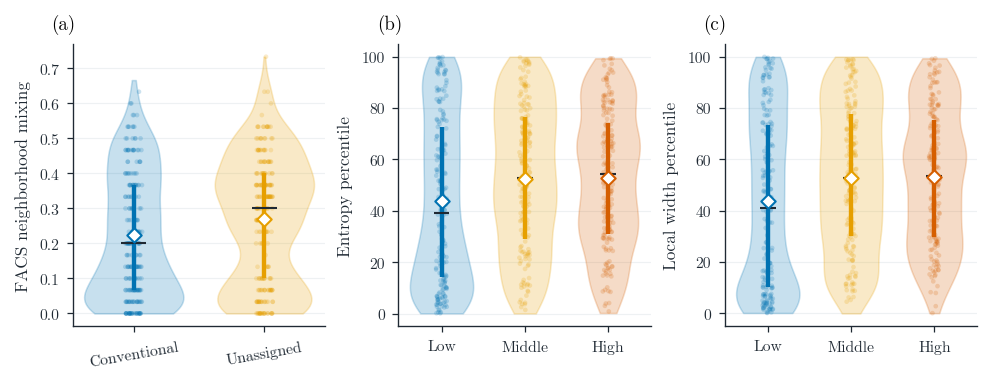

In [6]:
q25, q75 = np.quantile(facs_boundary[evaluation], [0.25, 0.75])
boundary_groups = [
    evaluation & (facs_boundary <= q25),
    evaluation & (facs_boundary > q25) & (facs_boundary < q75),
    evaluation & (facs_boundary >= q75),
]
fig, axes = plt.subplots(1, 3, figsize=(bmts.TEXT_WIDTH_IN, 2.45), constrained_layout=True)
bmts.draw_violin_summary(
    axes[0], [facs_boundary[known & evaluation], facs_boundary[(~known) & evaluation]],
    [bmts.BLUE, bmts.ORANGE], seed=9283, max_points=220,
)
axes[0].set_xticks([1, 2], ["Conventional", "Unassigned"], rotation=10)
axes[0].set_ylabel("FACS neighborhood mixing")

bmts.draw_violin_summary(
    axes[1], [100 * entropy_rank[mask] for mask in boundary_groups],
    [bmts.BLUE, bmts.ORANGE, bmts.VERMILLION], seed=9284, max_points=180,
)
axes[1].set_xticks([1, 2, 3], ["Low", "Middle", "High"])
axes[1].set_ylabel("Entropy percentile")

bmts.draw_violin_summary(
    axes[2], [100 * width_rank[mask] for mask in boundary_groups],
    [bmts.BLUE, bmts.ORANGE, bmts.VERMILLION], seed=9285, max_points=180,
)
axes[2].set_xticks([1, 2, 3], ["Low", "Middle", "High"])
axes[2].set_ylabel("Local width percentile")
for index, ax in enumerate(axes):
    bmts.panel_label(ax, f"({chr(97 + index)})")
plt.show()


**Figure 3.** Panel (a) compares external FACS mixing for conventionally gated and fine-gate-unassigned cells. Panels (b) and (c) compare the RNA-derived uncertainty summaries across low, middle, and high FACS-mixing groups. These are descriptive gradients, not new cell-type assignments.


In [7]:
# Remove linear QC trends from percentile ranks before the adjusted association.
qc_design = np.column_stack([
    np.ones(len(X)),
    StandardScaler().fit_transform(np.column_stack([np.log1p(library), np.log1p(detected), ercc])),
])
entropy_residual = entropy_rank - qc_design @ np.linalg.lstsq(qc_design, entropy_rank, rcond=None)[0]
width_residual = width_rank - qc_design @ np.linalg.lstsq(qc_design, width_rank, rcond=None)[0]
adjusted_entropy = spearmanr(entropy_residual[evaluation], facs_boundary[evaluation])
adjusted_width = spearmanr(width_residual[evaluation], facs_boundary[evaluation])

# Bootstrap and permutation remain within gate-by-broad-phenotype strata.
strata = np.char.add(np.char.add(gate, "|"), broad)
stratum_indices = [
    np.flatnonzero((strata == level) & evaluation)
    for level in np.unique(strata)
    if np.any((strata == level) & evaluation)
]
n_resamples = 1000 if PAPER_SCALE else 400
rng = np.random.default_rng(9273)
boot_entropy = np.empty(n_resamples); boot_width = np.empty(n_resamples)
perm_entropy = np.empty(n_resamples); perm_width = np.empty(n_resamples)
for replicate in range(n_resamples):
    sampled = np.concatenate([rng.choice(index, size=len(index), replace=True) for index in stratum_indices])
    boot_entropy[replicate] = spearmanr(entropy[sampled], facs_boundary[sampled]).statistic
    boot_width[replicate] = spearmanr(local_width[sampled], facs_boundary[sampled]).statistic
    permuted = facs_boundary.copy()
    for index in stratum_indices:
        permuted[index] = facs_boundary[rng.permutation(index)]
    perm_entropy[replicate] = spearmanr(entropy[evaluation], permuted[evaluation]).statistic
    perm_width[replicate] = spearmanr(local_width[evaluation], permuted[evaluation]).statistic

inference = pd.DataFrame(
    {
        "summary": ["Responsibility entropy", "Local BMTS width"],
        "rho": [rho_entropy.statistic, rho_width.statistic],
        "stratified bootstrap low": [np.quantile(boot_entropy, 0.025), np.quantile(boot_width, 0.025)],
        "stratified bootstrap high": [np.quantile(boot_entropy, 0.975), np.quantile(boot_width, 0.975)],
        "stratified permutation p": [
            (1 + np.sum(np.abs(perm_entropy) >= abs(rho_entropy.statistic))) / (n_resamples + 1),
            (1 + np.sum(np.abs(perm_width) >= abs(rho_width.statistic))) / (n_resamples + 1),
        ],
        "QC-adjusted rho": [adjusted_entropy.statistic, adjusted_width.statistic],
    }
)
inference.round(4)


,summary,rho,stratified bootstrap low,stratified bootstrap high,stratified permutation p,QC-adjusted rho
0,Responsibility entropy,0.1009,0.0499,0.1549,0.0125,0.0874
1,Local BMTS width,0.1001,0.0460,0.1584,0.0075,0.0924


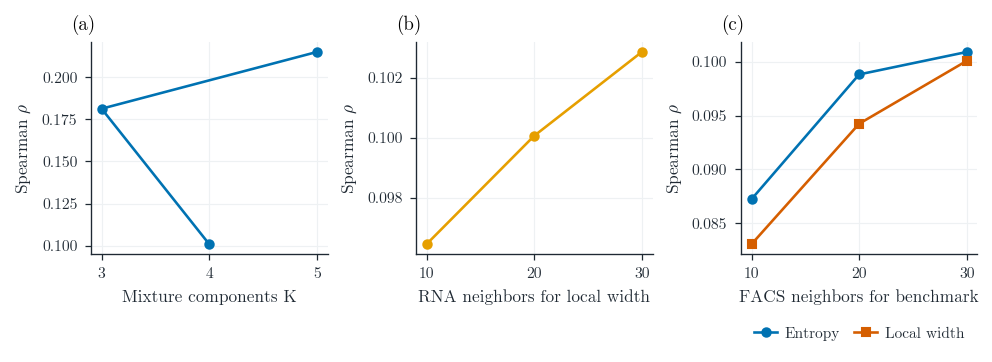

,setting,rho
0,K=3,0.181
1,K=4,0.101
2,K=5,0.215
3,RNA NN=10,0.096
4,RNA NN=20,0.100
5,RNA NN=30,0.103


In [8]:
# Mixture-granularity sensitivity uses entropy only and never consults FACS labels when fitting.
k_association = {4: rho_entropy.statistic}
for components in (3, 5):
    initial_k = KMeans(n_clusters=components, n_init=30, random_state=9271).fit(X)
    covariance_k = bmts.pooled_within_covariance(X, initial_k.labels_, ridge=0.05)
    sensitivity_settings = (
        {"iterations": 800, "burn": 300, "thin": 5}
        if PAPER_SCALE
        else {"iterations": 500, "burn": 200, "thin": 6}
    )
    fit_k = bmts.sample_common_covariance_gmm(
        X, components, covariance_k, seed=9271 + components,
        initial_labels=initial_k.labels_, concentration=1.0, prior_scale=25.0,
        **sensitivity_settings,
    )
    entropy_k = bmts.responsibility_entropy(fit_k.responsibilities)
    k_association[components] = spearmanr(entropy_k[evaluation], facs_boundary[evaluation]).statistic

rna_association = {
    neighbors: spearmanr(
        bmts.local_pair_medians(posterior.width, rna_neighbors, pairs, neighbors=neighbors)[evaluation],
        facs_boundary[evaluation],
    ).statistic
    for neighbors in (10, 20, 30)
}
facs_entropy_association = {
    neighbors: spearmanr(entropy[evaluation], facs_scores[neighbors][evaluation]).statistic
    for neighbors in (10, 20, 30)
}
facs_width_association = {
    neighbors: spearmanr(local_width[evaluation], facs_scores[neighbors][evaluation]).statistic
    for neighbors in (10, 20, 30)
}

fig, axes = plt.subplots(1, 3, figsize=(bmts.TEXT_WIDTH_IN, 2.25), constrained_layout=True)
axes[0].plot(list(k_association), list(k_association.values()), marker="o", color=bmts.BLUE)
axes[0].set(xlabel="Mixture components K", ylabel=r"Spearman $\rho$")
axes[0].set_xticks([3, 4, 5])

axes[1].plot(list(rna_association), list(rna_association.values()), marker="o", color=bmts.ORANGE)
axes[1].set(xlabel="RNA neighbors for local width", ylabel=r"Spearman $\rho$")
axes[1].set_xticks([10, 20, 30])

axes[2].plot(list(facs_entropy_association), list(facs_entropy_association.values()), marker="o", color=bmts.BLUE, label="Entropy")
axes[2].plot(list(facs_width_association), list(facs_width_association.values()), marker="s", color=bmts.VERMILLION, label="Local width")
axes[2].set(xlabel="FACS neighbors for benchmark", ylabel=r"Spearman $\rho$")
axes[2].set_xticks([10, 20, 30])
axes[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)
for index, ax in enumerate(axes):
    bmts.finish_axes(ax, "both")
    bmts.panel_label(ax, f"({chr(97 + index)})")
plt.show()

pd.DataFrame(
    {
        "setting": ["K=3", "K=4", "K=5", "RNA NN=10", "RNA NN=20", "RNA NN=30"],
        "rho": [k_association[3], k_association[4], k_association[5], rna_association[10], rna_association[20], rna_association[30]],
    }
).round(3)


**Figure 4.** Sensitivity of the withheld FACS association to (a) mixture granularity, (b) the RNA neighborhood used for local interval width, and (c) the FACS neighborhood defining the external benchmark. The direction is stable across these choices, but the effect sizes remain small. Together with the adjusted and stratified analyses above, this supports a cautious interpretation: diffuse responsibilities and locally wide BMTS intervals tend to occur near boundary-like cells, while neither quantity is a standalone biological classifier.
